# Relationship Between Snowmelt Timing and Vegetation Dynamics (1988–2022)

This section investigates the long-term relationship between snowmelt timing and vegetation dynamics across the Arctic during 1988–2022. Because MED exhibited the strongest agreement with independent reference datasets and the most robust long-term trends among the snowmelt metrics, it was selected as the primary indicator of snowmelt timing.

Long-term trends in MED and NDVI-derived vegetation indicators were analyzed separately over the 35-year period. In addition, pixel-wise Spearman correlations were calculated between annual MED and annual vegetation indicators, including annual maximum NDVI, peak NDVI timing, and start of season (SOS). These temporal correlations assess whether interannual variations in snowmelt timing are associated with corresponding variations in vegetation activity and phenology at each pixel.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import re
import xarray as xr
from datetime import timedelta
import datetime
from netCDF4 import num2date
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.patheffects as pe
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import linregress, spearmanr
from pymannkendall import original_test
import matplotlib.colors as mcolors
from scipy.stats import kendalltau

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/Users/nayou/data'
    data_FP = '/Users/nayou/journal_publish/NC_files' 
    #cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    #nas_data_FP = '/home/nayoung/nas_data'
    #data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Create the land mask for regions north of 60°N

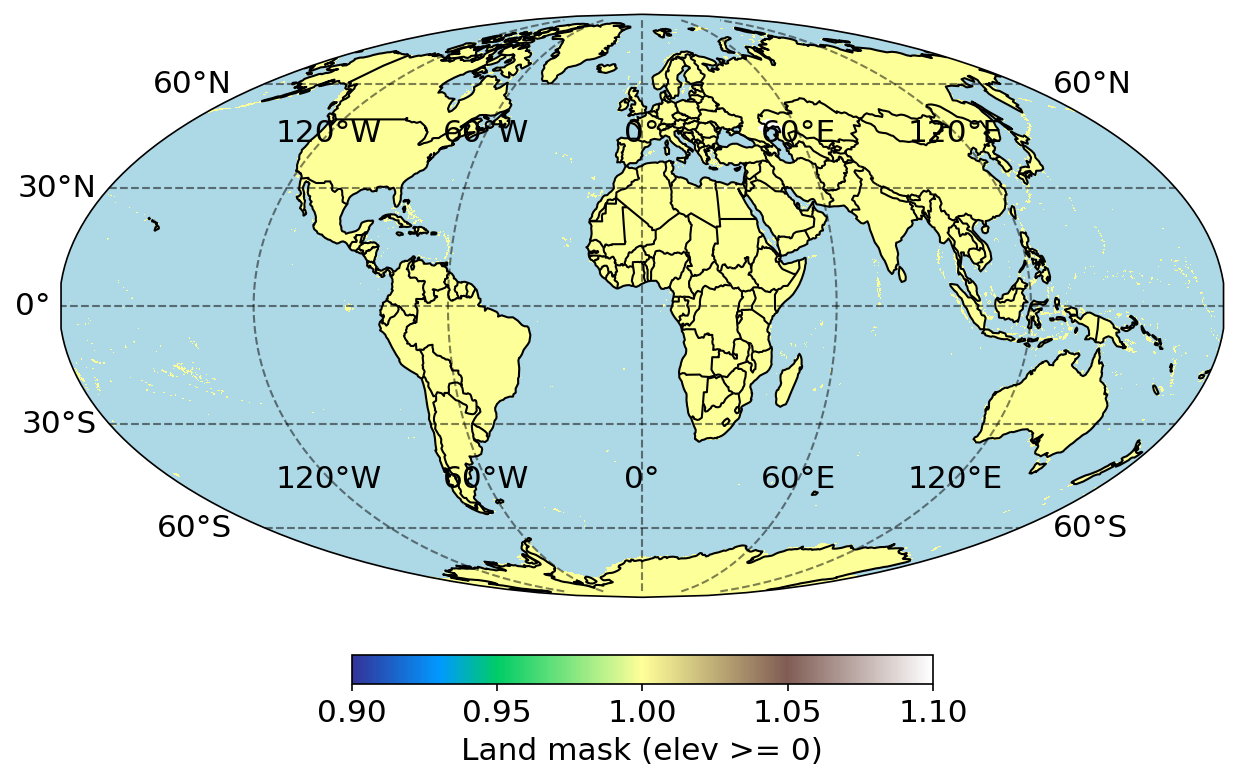

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

#DEM_path = '/home/nayoung/nas_data/DEM'
DEM_25km = "C:/Users/nayou/journal_publish/NC_files/Files/DEM_25km.nc"
#Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
#DEM_25km = nc.Dataset(Find_DEM_File[0])

with nc.Dataset(DEM_25km) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [3]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None, markers=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = mcolors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='both',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    if markers is not None:
        for m in markers:
            ax.scatter(
                m["lon"],
                m["lat"],
                transform=ccrs.PlateCarree(),
                marker=m.get("marker", "o"),
                s=m.get("size", 300),
                color=m.get("color", "red"),
                edgecolor=m.get("edgecolor", "black"),
                linewidth=m.get("linewidth", 1.4),
                zorder=20
            )

    if label_title is not None:
        ax.set_title(label_title, fontsize=16, pad=20)

    return fig, ax

## Load the snowmelt and cluster-related data and define the functions

In [4]:
#Pettitt_MED_file_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MED_pettitt_250window_MA5_meanstd_1988_2022.nc'
#TB_cluster_map_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc'
#permafrost_mask_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask'
Pettitt_MED_file_path = "C:/Users/nayou/journal_publish/NC_files//Files/MED_pettitt_250window_MA5_meanstd_1988_2022.nc"
TB_cluster_map_path = "C:/Users/nayou/journal_publish/NC_files/Files/TB_cluster_map.nc"
permafrost_mask_path = "C:/Users/nayou/journal_publish/NC_files/Permafrost_waterbody_mask/waterbody_mask"

with nc.Dataset(Pettitt_MED_file_path) as ds:
    MED_doy = ds.variables['MED_doy'][:]
    Tau = ds.variables['TAU_doy'][:]
    lon = ds.variables['lon'][:]
    lat = ds.variables['lat'][:]

with nc.Dataset(TB_cluster_map_path) as ds:
    TB_cluster = ds.variables['TB_cluster'][:]  # (lat, lon)

In [5]:
def load_mask_for_year(y):
    yfile = 1992 if y <= 1992 else y
    fpath = f"{permafrost_mask_path}/Permafrost_waterbody_mask_25km_{yfile}.nc"
    with nc.Dataset(fpath) as ds:
        snowice_mask = ds.variables['snowice_mask'][:]
        waterbody_mask = ds.variables['water_mask'][:]
    mask = np.isfinite(snowice_mask) & np.isfinite(waterbody_mask)
    return mask.astype(np.uint8)


def mann_kendall_test(y):
    """
    Returns tau, p-value
    """
    x = np.arange(len(y))
    mask = np.isfinite(y)
    if np.sum(mask) < 5:
        return np.nan, np.nan
    tau, p = kendalltau(x[mask], y[mask])
    return tau, p


def sens_slope(y):
    """
    Sen's slope (days/year)
    """
    mask = np.isfinite(y)
    y = y[mask]
    x = np.arange(len(y))

    if len(y) < 5:
        return np.nan

    slopes = []
    for i in range(len(y)-1):
        for j in range(i+1, len(y)):
            slopes.append((y[j] - y[i]) / (j - i))
    return np.median(slopes)

## 35-year MED Trend Analysis

In [6]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30

if np.ma.isMaskedArray(MED_doy):
    MED_doy = MED_doy.filled(np.nan)
MED_doy = np.array(MED_doy, dtype=np.float32, copy=True)

# Exclude cluster 3 globally
MED_doy[TB_cluster == 3, :] = np.nan

# Only for DOY < 250
MED_doy[(MED_doy > 250)] = np.nan

for yi, year in enumerate(range(start_year, end_year+1)):
    bad = (load_mask_for_year(year) == 0)
    slice_y = MED_doy[:, :, yi]
    slice_y[bad] = np.nan
    MED_doy[:, :, yi] = slice_y

lat_n, lon_n = MED_doy.shape[:2]
mk_tau_med   = np.full((lat_n, lon_n), np.nan)
mk_p_med     = np.full((lat_n, lon_n), np.nan)
mk_trend_med = np.full((lat_n, lon_n), 0, dtype=np.int8)  
mk_slope_med = np.full((lat_n, lon_n), np.nan)            # Sen’s slope (days/year)

for i in range(lat_n):
    for j in range(lon_n):
        series = MED_doy[i, j, :]
        valid = ~np.isnan(series)
        if np.count_nonzero(valid) < min_years:
            continue
        try:
            res = original_test(series[valid])
            mk_tau_med[i, j]   = res.Tau
            mk_p_med[i, j]     = res.p
            mk_trend_med[i, j] = 1 if res.trend == 'increasing' else (-1 if res.trend == 'decreasing' else 0)
            mk_slope_med[i, j] = res.slope      
        except Exception:
            pass

### Sen’s slope of Pettitt-derived MED, shown only for pixels significant at the 95% confidence level (p < 0.05)

Mean slope for 95% significant MED (days/year): -0.30828814643013197
Median slope for 95% significant MED (days/year): -0.38095238095238093
Total significant pixels (p < 0.05): 12321
Number of decreasing pixels: 10958
Number of increasing pixels: 1363
Number of no-trend pixels: 0


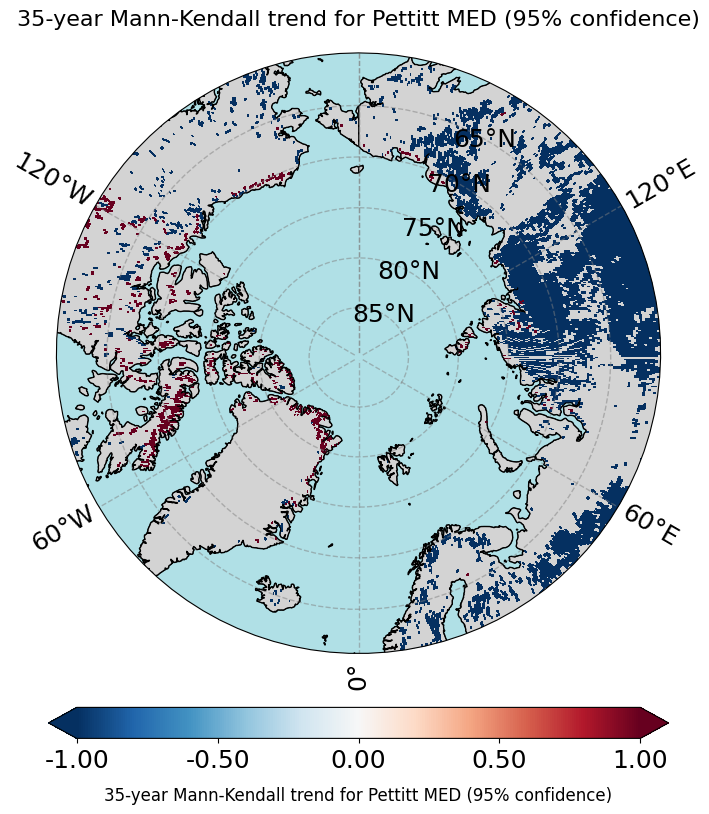

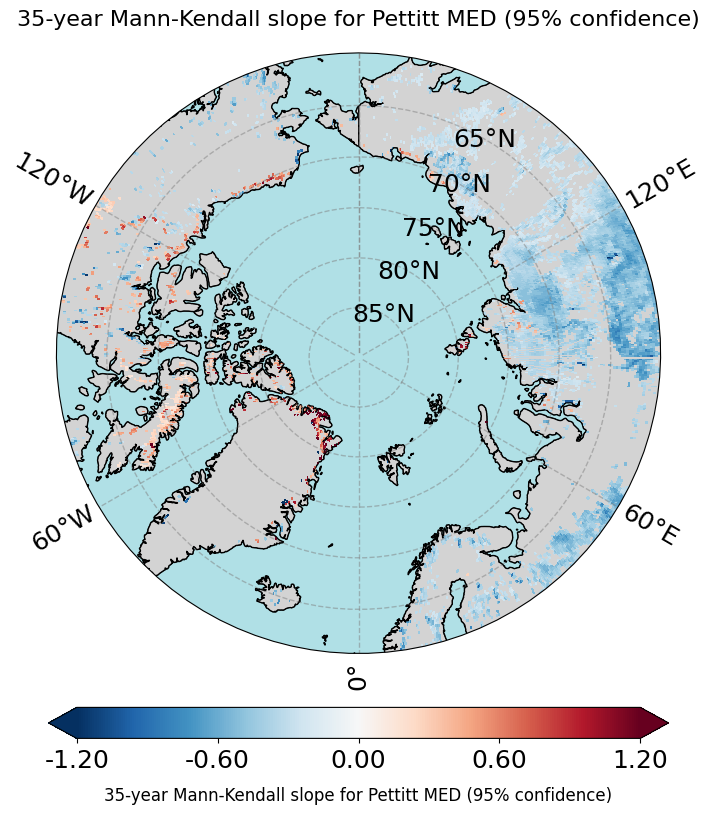

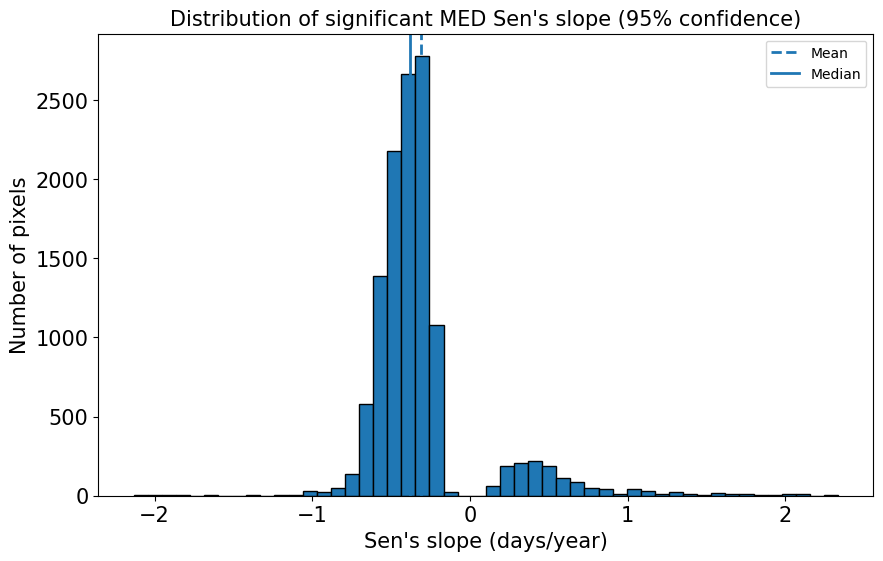

Total pixels in histogram: 12321


In [7]:
domain_lon, domain_lat = np.meshgrid(lon, lat)

# Set significance level
significant_level_med = 0.05
confidence_level_med = int((1 - significant_level_med) * 100)

# Redefine significant trend direction using p-value and Sen's slope sign
mk_trend_redefined_med = np.full(mk_slope_med.shape, np.nan, dtype=float)

mk_trend_redefined_med[(mk_p_med < significant_level_med) & (mk_slope_med < 0)] = -1
mk_trend_redefined_med[(mk_p_med < significant_level_med) & (mk_slope_med > 0)] = 1
mk_trend_redefined_med[(mk_p_med < significant_level_med) & (mk_slope_med == 0)] = 0

# Plot trend direction
fig_trend_med, ax_trend_med = plot_Northpole(
    domain_lon,
    domain_lat,
    mk_trend_redefined_med,
    label_title=f"35-year Mann-Kendall trend for Pettitt MED ({confidence_level_med}% confidence)",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    vcenter=0
)

# Plot Sen's slope with only significant pixels
mk_slope_significant_med = np.where(
    mk_p_med < significant_level_med,
    mk_slope_med,
    np.nan
)

fig_slope_med, ax_slope_med = plot_Northpole(
    domain_lon,
    domain_lat,
    mk_slope_significant_med,
    label_title=f"35-year Mann-Kendall slope for Pettitt MED ({confidence_level_med}% confidence)",
    cmap="RdBu_r",
    vmin=-1.2,
    vmax=1.2,
    vcenter=0
)


# Statistics
slope_vals_med = mk_slope_significant_med[np.isfinite(mk_slope_significant_med)]

print(f"Mean slope for {confidence_level_med}% significant MED (days/year):", np.nanmean(slope_vals_med))
print(f"Median slope for {confidence_level_med}% significant MED (days/year):", np.nanmedian(slope_vals_med))

# Count decreasing/increasing pixels
total_significant_pixels_med = np.sum(np.isfinite(mk_trend_redefined_med))
decreasing_pixels_med = np.sum(mk_trend_redefined_med == -1)
increasing_pixels_med = np.sum(mk_trend_redefined_med == 1)
no_trend_pixels_med = np.sum(mk_trend_redefined_med == 0)

print(f"Total significant pixels (p < {significant_level_med}): {total_significant_pixels_med}")
print(f"Number of decreasing pixels: {decreasing_pixels_med}")
print(f"Number of increasing pixels: {increasing_pixels_med}")
print(f"Number of no-trend pixels: {no_trend_pixels_med}")

if total_significant_pixels_med != (
    decreasing_pixels_med + increasing_pixels_med + no_trend_pixels_med
):
    print("Warning: Pixel count mismatch!")

# Histogram of significant Sen's slope values
plt.figure(figsize=(10, 6))
plt.hist(slope_vals_med, bins=50, edgecolor="black")
plt.axvline(np.nanmean(slope_vals_med), linestyle="--", linewidth=2, label="Mean")
plt.axvline(np.nanmedian(slope_vals_med), linestyle="-", linewidth=2, label="Median")

plt.xlabel("Sen's slope (days/year)")
plt.ylabel("Number of pixels")
plt.title(f"Distribution of significant MED Sen's slope ({confidence_level_med}% confidence)")
plt.legend()
plt.show()

print("Total pixels in histogram:", slope_vals_med.size)


## GIMMS NDVI Preprocessing and Resampling

This section preprocesses the GIMMS NDVI3g dataset and resamples it onto the 25 km EASE-Grid 2.0 domain used throughout this study. The original half-monthly NDVI observations from 1982–2022 were first screened for invalid values and converted to physical NDVI units using the provided scale factor.

Specifically, fill values (-32768 and -5000) were treated as missing data, and all NDVI values were scaled by a factor of 0.0001. Values outside the valid NDVI range (-1 to 1) were subsequently removed. The resulting NDVI fields were then resampled from the original GIMMS grid to the 25 km EASE-Grid 2.0 domain using a nearest-neighbor search combined with spatial averaging.

To ensure consistency with the snowmelt analysis domain, a land mask was applied to remove non-land grid cells. Each half-monthly NDVI layer was saved as an individual NetCDF file containing the resampled NDVI field and corresponding acquisition date. The processed NDVI dataset serves as the basis for deriving annual maximum NDVI, the timing of annual maximum NDVI, and the start of season (SOS), which are subsequently used to investigate long-term relationships between vegetation dynamics and snowmelt timing.


In [ ]:
# Open GIMMS NDVI
start_year = 1982
end_year = 2022

domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

base_in_dir = f'{cpuserver_data_FP}/personal_data/project_snow/NDVI/NDVI_GIMMS'
base_out_dir = f'{cpuserver_data_FP}/personal_data/project_snow/NDVI/NDVI_GIMMS/NDVI_25km_new'
os.makedirs(base_out_dir, exist_ok=True)

for year in range(start_year, end_year + 1):

    GIMMS_NDVI_path = os.path.join(base_in_dir, str(year))
    find_nc_file = sorted(glob.glob(os.path.join(GIMMS_NDVI_path, '*.nc4')))

    print(f"\nProcessing {year}: {len(find_nc_file)} files")

    if len(find_nc_file) == 0:
        print(f"No files found for {year}")
        continue

    for file_idx, nc_file in enumerate(find_nc_file):

        print(f"\nProcessing file {file_idx + 1}/{len(find_nc_file)}: {os.path.basename(nc_file)}")

        with nc.Dataset(nc_file, 'r') as src:

            lat = src.variables['lat'][:]
            lon = src.variables['lon'][:]

            time_var = src.variables['time']
            time_values = time_var[:]

            dates = num2date(
                time_values,
                units=time_var.units,
                calendar=getattr(time_var, 'calendar', 'standard')
            )

            ndvi_data = src.variables['ndvi'][:]

            print(f"Time values: {time_values}")
            print(f"First date: {dates[0]}, Last date: {dates[-1]}")
            print(f"File contains {ndvi_data.shape[0]} NDVI layers")

            original_lon, original_lat = np.meshgrid(lon, lat)

            for ndvi_idx in range(ndvi_data.shape[0]):

                current_date = dates[ndvi_idx]

                File_year = current_date.year
                File_month = current_date.month
                File_day = current_date.day

                print(
                    f"  Processing NDVI layer {ndvi_idx + 1}/{ndvi_data.shape[0]}: "
                    f"{File_year}-{File_month:02d}-{File_day:02d}"
                )

                ndvi_layer = ndvi_data[ndvi_idx].astype(np.float32)

                # Process missing values
                ndvi_layer[ndvi_layer == -32768.0] = np.nan
                ndvi_layer[ndvi_layer == -5000.0] = np.nan

                # Apply the scale factor
                ndvi_layer = ndvi_layer / 10000.0

                # Remove values outside the valid NDVI range
                ndvi_layer[(ndvi_layer < -1.0) | (ndvi_layer > 1.0)] = np.nan

                # Resample into 25 km grid
                resampled_ndvi = hData.Resampling(
                    domain_lon,
                    domain_lat,
                    original_lon,
                    original_lat,
                    ndvi_layer,
                    'nearest',
                    'mean',
                    mag_factor=2
                )

                # Apply land mask
                resampled_ndvi = np.where(land_mask, resampled_ndvi, np.nan)

                output_path = os.path.join(base_out_dir, str(File_year))
                os.makedirs(output_path, exist_ok=True)

                output_file_name = (
                    f'GIMMS_NDVI_{File_year}_{File_month:02d}_{File_day:02d}_25km.nc'
                )

                output_full_path = os.path.join(output_path, output_file_name)

                with nc.Dataset(output_full_path, 'w', format='NETCDF4') as dst:

                    dst.createDimension('time', 1)
                    dst.createDimension('lat', domain_lat.shape[0])
                    dst.createDimension('lon', domain_lon.shape[1])

                    time_out = dst.createVariable('time', 'f8', ('time',))
                    lat_out = dst.createVariable('lat', 'f8', ('lat',))
                    lon_out = dst.createVariable('lon', 'f8', ('lon',))
                    ndvi_out = dst.createVariable(
                        'NDVI',
                        'f4',
                        ('lat', 'lon'),
                        zlib=True,
                        fill_value=np.nan
                    )

                    reference_date = datetime.datetime(1982, 1, 1)
                    file_date = datetime.datetime(File_year, File_month, File_day)
                    days_since_ref = (file_date - reference_date).days

                    time_out[:] = [days_since_ref]
                    lat_out[:] = domain_lat[:, 0]
                    lon_out[:] = domain_lon[0, :]
                    ndvi_out[:, :] = resampled_ndvi

                    time_out.units = 'days since 1982-01-01 00:00:00'
                    time_out.calendar = 'standard'
                    time_out.long_name = 'middle day of each half-month period'

                    lat_out.units = 'degrees_north'
                    lon_out.units = 'degrees_east'

                    ndvi_out.units = '-'
                    ndvi_out.long_name = 'Normalized Difference Vegetation Index'
                    ndvi_out.missing_value = np.nan

                    dst.description = 'Resampled GIMMS NDVI to 25 km grid'
                    dst.source_file = os.path.basename(nc_file)

                print(f"  Saved to: {output_full_path}")


## Derivation of Annual Maximum NDVI and Peak Growing Season Timing

### Define functions

In [8]:
# Get date from filename
def get_date_from_filename(fname):
    m = re.search(r'GIMMS_NDVI_(\d{4})_(\d{2})_(\d{2})', os.path.basename(fname))
    if m is None:
        raise ValueError(f"Cannot parse date from filename: {fname}")

    y, mth, d = map(int, m.groups())
    date = pd.Timestamp(year=y, month=mth, day=d)
    return date, date.dayofyear


# Calculate Mann-Kendall trend
def calculate_mk_sen_trend(data_3d, min_years=30):
    """
    data_3d shape: lat, lon, year
    """

    lat_n, lon_n = data_3d.shape[:2]

    mk_tau = np.full((lat_n, lon_n), np.nan)
    mk_p = np.full((lat_n, lon_n), np.nan)
    mk_trend = np.full((lat_n, lon_n), 0, dtype=np.int8)
    mk_slope = np.full((lat_n, lon_n), np.nan)

    for i in range(lat_n):
        for j in range(lon_n):
            series = data_3d[i, j, :]
            valid = np.isfinite(series)

            if np.count_nonzero(valid) < min_years:
                continue

            try:
                res = original_test(series[valid])

                mk_tau[i, j] = res.Tau
                mk_p[i, j] = res.p
                mk_trend[i, j] = (
                    1 if res.trend == 'increasing'
                    else -1 if res.trend == 'decreasing'
                    else 0
                )
                mk_slope[i, j] = res.slope

            except Exception:
                pass

    return mk_tau, mk_p, mk_trend, mk_slope


# Plot / stats function
def plot_and_summarize_trend(
    mk_p,
    mk_slope,
    domain_lon,
    domain_lat,
    var_name,
    slope_unit,
    significant_level=0.05,
    slope_vmin=None,
    slope_vmax=None
):

    confidence_level = int((1 - significant_level) * 100)

    mk_trend_redefined = np.full(mk_slope.shape, np.nan, dtype=float)

    mk_trend_redefined[(mk_p < significant_level) & (mk_slope < 0)] = -1
    mk_trend_redefined[(mk_p < significant_level) & (mk_slope > 0)] = 1
    mk_trend_redefined[(mk_p < significant_level) & (mk_slope == 0)] = 0

    # Plot the trend
    fig_trend, ax_trend = plot_Northpole(
        domain_lon,
        domain_lat,
        mk_trend_redefined,
        label_title=None,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        vcenter=0
    )

    mk_slope_significant = np.where(
        mk_p < significant_level,
        mk_slope,
        np.nan
    )

    # Plot the slope
    fig_slope, ax_slope = plot_Northpole(
        domain_lon,
        domain_lat,
        mk_slope_significant,
        label_title=None,
        cmap="RdBu_r",
        vmin=slope_vmin,
        vmax=slope_vmax,
        vcenter=0
    )

    slope_vals = mk_slope_significant[np.isfinite(mk_slope_significant)]

    print(f"\n===== {var_name} =====")
    print(f"Mean slope for {confidence_level}% significant {var_name} ({slope_unit}):", np.nanmean(slope_vals))
    print(f"Median slope for {confidence_level}% significant {var_name} ({slope_unit}):", np.nanmedian(slope_vals))

    total_significant_pixels = np.sum(np.isfinite(mk_trend_redefined))
    decreasing_pixels = np.sum(mk_trend_redefined == -1)
    increasing_pixels = np.sum(mk_trend_redefined == 1)
    no_trend_pixels = np.sum(mk_trend_redefined == 0)

    print(f"Total significant pixels (p < {significant_level}): {total_significant_pixels}")
    print(f"Number of decreasing pixels: {decreasing_pixels}")
    print(f"Number of increasing pixels: {increasing_pixels}")
    print(f"Number of no-trend pixels: {no_trend_pixels}")

    if total_significant_pixels != (
        decreasing_pixels + increasing_pixels + no_trend_pixels
    ):
        print("Warning: Pixel count mismatch!")

    plt.figure(figsize=(10, 6))
    plt.hist(slope_vals, bins=50, edgecolor="black")
    plt.axvline(np.nanmean(slope_vals), linestyle="--", linewidth=2, label="Mean")
    plt.axvline(np.nanmedian(slope_vals), linestyle="-", linewidth=2, label="Median")

    plt.xlabel(f"Sen's slope ({slope_unit})")
    plt.ylabel("Number of pixels")
    plt.title(f"Distribution of significant {var_name} Sen's slope ({confidence_level}% confidence)")
    plt.legend()
    plt.show()

    print("Total pixels in histogram:", slope_vals.size)

    return fig_trend, ax_trend, fig_slope, ax_slope, mk_trend_redefined, mk_slope_significant

In [ ]:
NDVI_file_path = f'{cpuserver_data_FP}/personal_data/project_snow/NDVI/NDVI_GIMMS/NDVI_25km_new'
start_year, end_year = 1988, 2022
out_dir = f'{cpuserver_data_FP}/personal_data/project_snow/NDVI/NDVI_GIMMS/annual_max_new'
os.makedirs(out_dir, exist_ok=True)

for year in range(start_year, end_year + 1):

    files = sorted(glob.glob(os.path.join(
        NDVI_file_path, f'GIMMS_NDVI_{year}_*.nc'
    )))

    if len(files) == 0:
        files = sorted(glob.glob(os.path.join(
            NDVI_file_path, str(year), f'GIMMS_NDVI_{year}_*.nc'
        )))

    print(f"{year}: {len(files)} files")

    if len(files) == 0:
        print(f"Skipped {year}: no files found")
        continue

    ndvi_list = []
    doy_list = []
    date_list = []

    lat = None
    lon = None

    for f in files:
        date, doy = get_date_from_filename(f)

        with nc.Dataset(f, 'r') as ds:

            ndvi = ds.variables['NDVI'][:]

            if lat is None:
                lat = ds.variables['lat'][:]
                lon = ds.variables['lon'][:]

            ndvi = np.array(ndvi, dtype=np.float32)

            if np.ma.isMaskedArray(ndvi):
                ndvi = ndvi.filled(np.nan)

            if ndvi.ndim == 3 and ndvi.shape[0] == 1:
                ndvi = ndvi[0, :, :]

            if ndvi.ndim != 2:
                raise ValueError(f"Unexpected NDVI shape in {f}: {ndvi.shape}")

            # Remove values outside the valid NDVI range
            ndvi[(ndvi < -1.0) | (ndvi > 1.0)] = np.nan

            ndvi_list.append(ndvi)
            doy_list.append(doy)
            date_list.append(date.strftime('%Y-%m-%d'))

    ndvi_stack = np.stack(ndvi_list, axis=2)  # lat, lon, time
    doy_arr = np.array(doy_list, dtype=np.int16)

    valid_mask = np.isfinite(ndvi_stack)
    all_nan_mask = ~np.any(valid_mask, axis=2)

    safe_stack = np.where(valid_mask, ndvi_stack, -9999.0)

    max_idx = np.argmax(safe_stack, axis=2)

    annual_max_ndvi = np.nanmax(safe_stack, axis=2).astype(np.float32)
    annual_max_doy = doy_arr[max_idx].astype(np.float32)

    annual_max_ndvi[all_nan_mask] = np.nan
    annual_max_doy[all_nan_mask] = np.nan

    out_path = os.path.join(out_dir, f'GIMMS_annual_max_NDVI_{year}.nc')

    with nc.Dataset(out_path, 'w', format='NETCDF4') as out_nc:

        out_nc.createDimension('lat', len(lat))
        out_nc.createDimension('lon', len(lon))

        lat_var = out_nc.createVariable('lat', 'f4', ('lat',))
        lon_var = out_nc.createVariable('lon', 'f4', ('lon',))

        max_ndvi_var = out_nc.createVariable(
            'annual_max_NDVI', 'f4', ('lat', 'lon'),
            zlib=True, complevel=4, fill_value=np.nan
        )

        max_doy_var = out_nc.createVariable(
            'annual_max_NDVI_DOY', 'f4', ('lat', 'lon'),
            zlib=True, complevel=4, fill_value=np.nan
        )

        lat_var[:] = lat
        lon_var[:] = lon
        max_ndvi_var[:, :] = annual_max_ndvi
        max_doy_var[:, :] = annual_max_doy

        lat_var.units = 'degrees_north'
        lon_var.units = 'degrees_east'

        max_ndvi_var.long_name = 'Annual maximum NDVI'
        max_ndvi_var.units = 'NDVI'

        max_doy_var.long_name = 'Day of year when annual maximum NDVI occurs'
        max_doy_var.units = 'day of year'

        out_nc.description = 'Annual maximum NDVI and corresponding DOY from GIMMS NDVI'
        out_nc.year = year
        out_nc.source = NDVI_file_path

    print(f"Saved: {out_path}")


## 35-year Trend Analysis of annual maximum NDVI and peak NDVI DOY

In [9]:
# Load annual max NDVI files
start_year, end_year = 1988, 2022
min_years = 30
#annual_max_dir = f'{cpuserver_data_FP}/personal_data/project_snow/NDVI/NDVI_GIMMS/annual_max_new'
annual_max_dir = "C:/Users/nayou/journal_publish/NC_files/Files/annual_max_new"
years = np.arange(start_year, end_year + 1)
annual_max_ndvi_list = []
annual_max_doy_list = []
lat = None
lon = None

for year in years:
    f = os.path.join(annual_max_dir, f'GIMMS_annual_max_NDVI_{year}.nc')

    if not os.path.exists(f):
        print(f"Missing file: {f}")
        continue

    with nc.Dataset(f, 'r') as ds:
        if lat is None:
            lat = ds.variables['lat'][:]
            lon = ds.variables['lon'][:]

        annual_max_ndvi = ds.variables['annual_max_NDVI'][:]
        annual_max_doy = ds.variables['annual_max_NDVI_DOY'][:]

        annual_max_ndvi = np.array(annual_max_ndvi, dtype=np.float32)
        annual_max_doy = np.array(annual_max_doy, dtype=np.float32)

        if np.ma.isMaskedArray(annual_max_ndvi):
            annual_max_ndvi = annual_max_ndvi.filled(np.nan)
        if np.ma.isMaskedArray(annual_max_doy):
            annual_max_doy = annual_max_doy.filled(np.nan)

        annual_max_ndvi_list.append(annual_max_ndvi)
        annual_max_doy_list.append(annual_max_doy)

annual_max_ndvi_all = np.stack(annual_max_ndvi_list, axis=2)  # lat, lon, year
annual_max_doy_all = np.stack(annual_max_doy_list, axis=2)    # lat, lon, year

print("annual_max_ndvi_all:", annual_max_ndvi_all.shape)
print("annual_max_doy_all:", annual_max_doy_all.shape)


# Common preprocessing (Exclude cluster 3 globally and cut NDVI above north of 60N)
annual_max_ndvi_all = annual_max_ndvi_all[lat > 60, :]
annual_max_doy_all = annual_max_doy_all[lat > 60, :]

annual_max_ndvi_all[TB_cluster == 3, :] = np.nan
annual_max_doy_all[TB_cluster == 3, :] = np.nan


# Apply yearly valid mask
for yi, year in enumerate(years):
    bad = (load_mask_for_year(year) == 0)

    slice_ndvi = annual_max_ndvi_all[:, :, yi]
    slice_doy = annual_max_doy_all[:, :, yi]

    slice_ndvi[bad] = np.nan
    slice_doy[bad] = np.nan

    annual_max_ndvi_all[:, :, yi] = slice_ndvi
    annual_max_doy_all[:, :, yi] = slice_doy


annual_max_ndvi_all: (720, 1440, 35)
annual_max_doy_all: (720, 1440, 35)


### Figure 3a-b. 35-Year Sen's Slope Analysis

(120, 1440)
(120, 1440)

===== annual maximum NDVI =====
Mean slope for 95% significant annual maximum NDVI (NDVI/year): 0.0018469559515974538
Median slope for 95% significant annual maximum NDVI (NDVI/year): 0.0020225817157376196
Total significant pixels (p < 0.05): 24095
Number of decreasing pixels: 5082
Number of increasing pixels: 19005
Number of no-trend pixels: 8


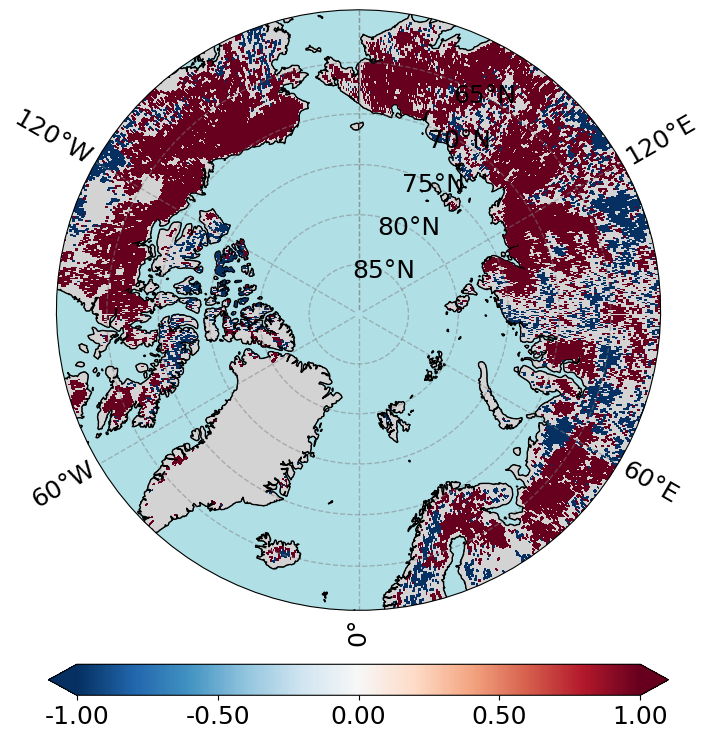

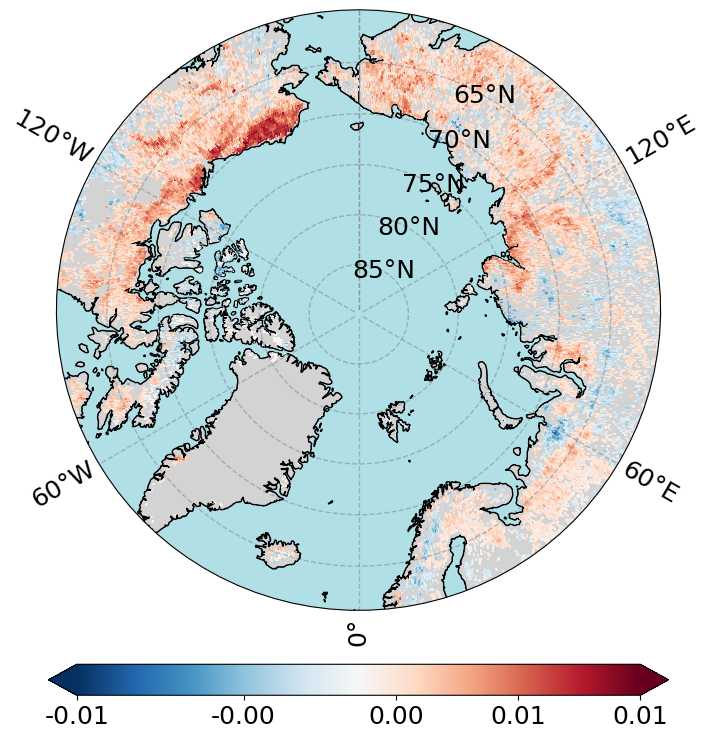

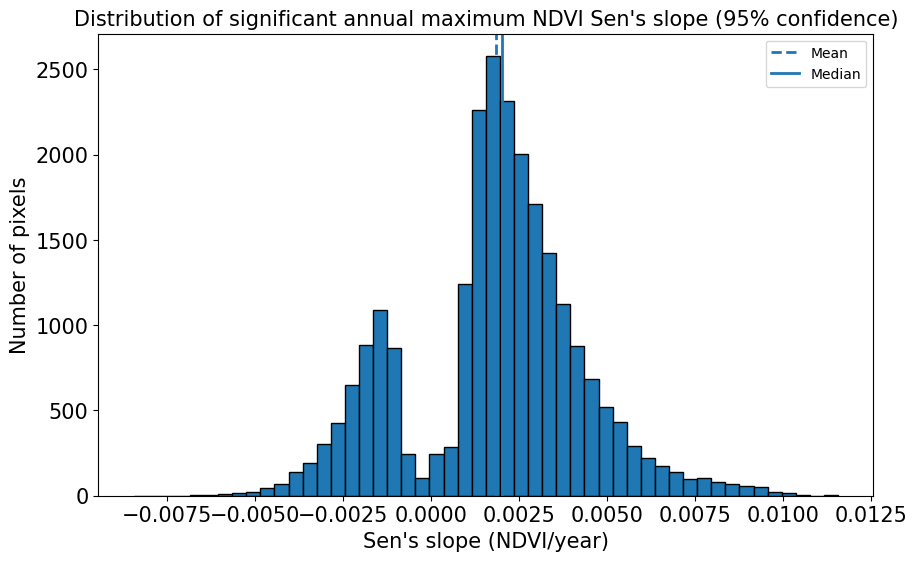

Total pixels in histogram: 24095
-0.008453703588909574
0.011572841140958998

===== peak NDVI DOY =====
Mean slope for 95% significant peak NDVI DOY (days/year): -0.2938128374376928
Median slope for 95% significant peak NDVI DOY (days/year): -0.14285714285714285
Total significant pixels (p < 0.05): 6365
Number of decreasing pixels: 5475
Number of increasing pixels: 290
Number of no-trend pixels: 600


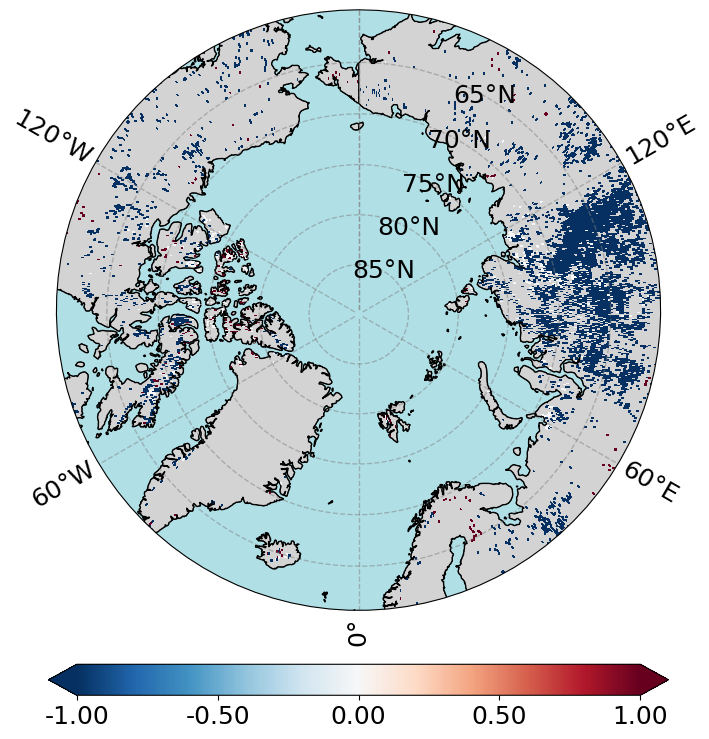

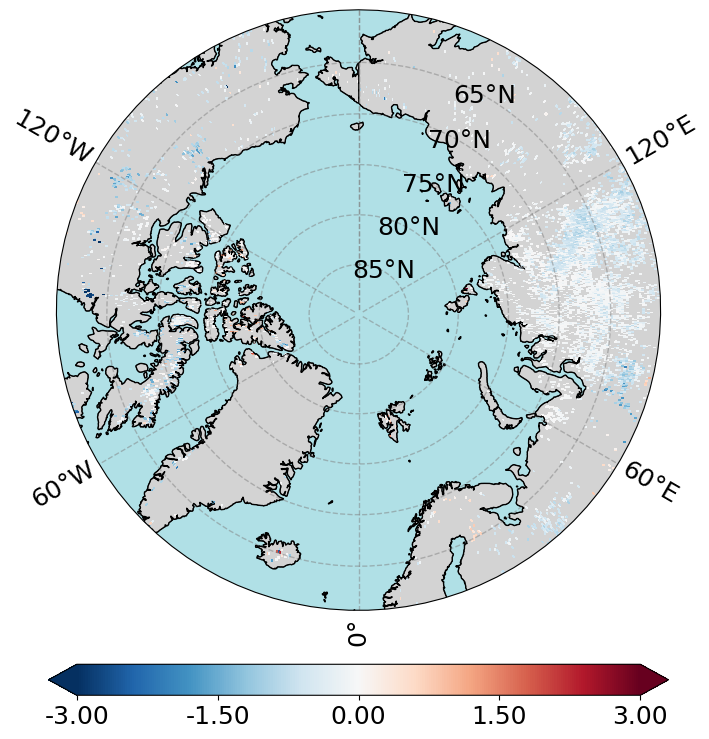

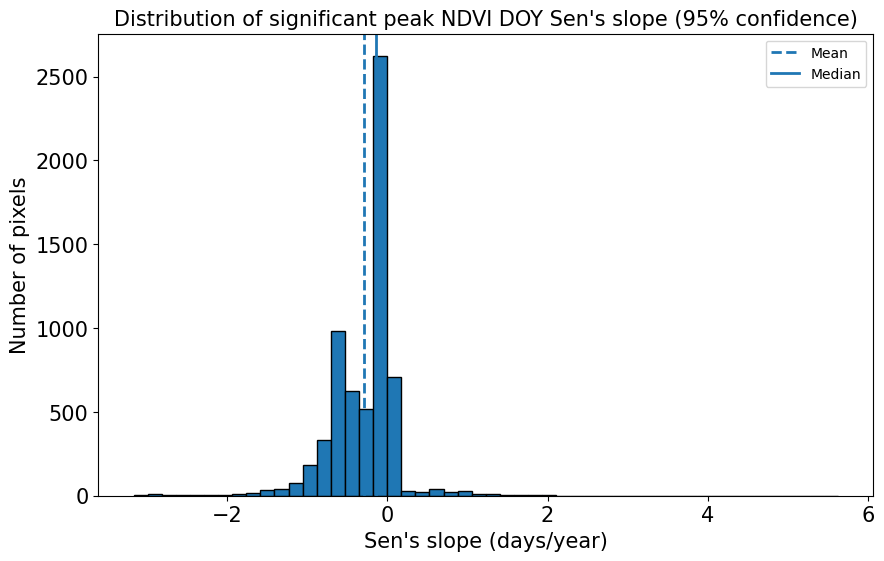

Total pixels in histogram: 6365
-3.1666666666666665
5.625


In [11]:
# Calculate trend
mk_tau_ndvi, mk_p_ndvi, mk_trend_ndvi, mk_slope_ndvi = calculate_mk_sen_trend(
    annual_max_ndvi_all,
    min_years=min_years
)

mk_tau_peakdoy, mk_p_peakdoy, mk_trend_peakdoy, mk_slope_peakdoy = calculate_mk_sen_trend(
    annual_max_doy_all,
    min_years=min_years
)

# Plot results
domain_lon, domain_lat = np.meshgrid(lon, lat)
domain_lat_60 = domain_lat[lat > 60, :]
domain_lon_60 = domain_lon[lat > 60, :]
print(domain_lat_60.shape)
print(domain_lon_60.shape)

significant_level = 0.05

# Annual maximum NDVI trend
fig_trend_ndvi, ax_trend_ndvi, fig_slope_ndvi, ax_slope_ndvi, trend_redefined_ndvi, slope_sig_ndvi = plot_and_summarize_trend(
    mk_p_ndvi,
    mk_slope_ndvi,
    domain_lon_60,
    domain_lat_60,
    var_name="annual maximum NDVI",
    slope_unit="NDVI/year",
    significant_level=significant_level,
    slope_vmin=np.nanmin(mk_slope_ndvi),
    slope_vmax=np.nanmax(mk_slope_ndvi)
)

print(np.nanmin(mk_slope_ndvi))
print(np.nanmax(mk_slope_ndvi))

# Peak NDVI DOY trend
fig_trend_peakdoy, ax_trend_peakdoy, fig_slope_peakdoy, ax_slope_peakdoy, trend_redefined_peakdoy, slope_sig_peakdoy = plot_and_summarize_trend(
    mk_p_peakdoy,
    mk_slope_peakdoy,
    domain_lon_60,
    domain_lat_60,
    var_name="peak NDVI DOY",
    slope_unit="days/year",
    significant_level=significant_level,
    slope_vmin=-3,
    slope_vmax=3
)

print(np.nanmin(mk_slope_peakdoy))
print(np.nanmax(mk_slope_peakdoy))

# Save the figure
#fig_slope_ndvi.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Annual Maximum NDVI Slope.png", dpi=300, bbox_inches="tight")
fig_slope_ndvi.savefig("C:/Users/nayou/journal_publish/Original_Figures_300dpi/Figures_300dpi/Trend/Annual_Maximum_NDVI_slope.png", dpi=300, bbox_inches="tight")
plt.close(fig_slope_ndvi)

#fig_slope_peakdoy.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Peak NDVI DOY Slope.png", dpi=300, bbox_inches="tight")
fig_slope_peakdoy.savefig("C:/Users/nayou/journal_publish/Original_Figures_300dpi/Figures_300dpi/Trend/Peak_NDVI_DOY_slope.png", dpi=300, bbox_inches="tight")
plt.close(fig_slope_peakdoy)


## Correlation Between Snowmelt Timing and Annual Maximum NDVI

To assess the influence of interannual snowmelt timing variability on vegetation productivity, pixel-wise Spearman correlations were calculated between annual MED and annual maximum NDVI during 1988–2022. Prior to the correlation analysis, both the MED and NDVI time series were linearly detrended using ordinary least-squares regression to remove shared long-term trends. The Spearman correlation was then calculated using the detrended residuals, allowing the analysis to examine whether year-to-year variations in snowmelt timing were associated with corresponding variations in peak vegetation greenness across the Arctic.

### Function to detrend the time series

In [14]:
def linear_detrend(ts):
    """
    Remove linear trend from a 1D time series.
    Returns residuals after least-squares linear regression.
    """
    ts = np.asarray(ts, dtype=float)

    x = np.arange(len(ts))

    slope, intercept, _, _, _ = linregress(x, ts)

    trend = slope * x + intercept

    return ts - trend

### Figure 3c. Interannual Spearman Correlation Analysis with MED

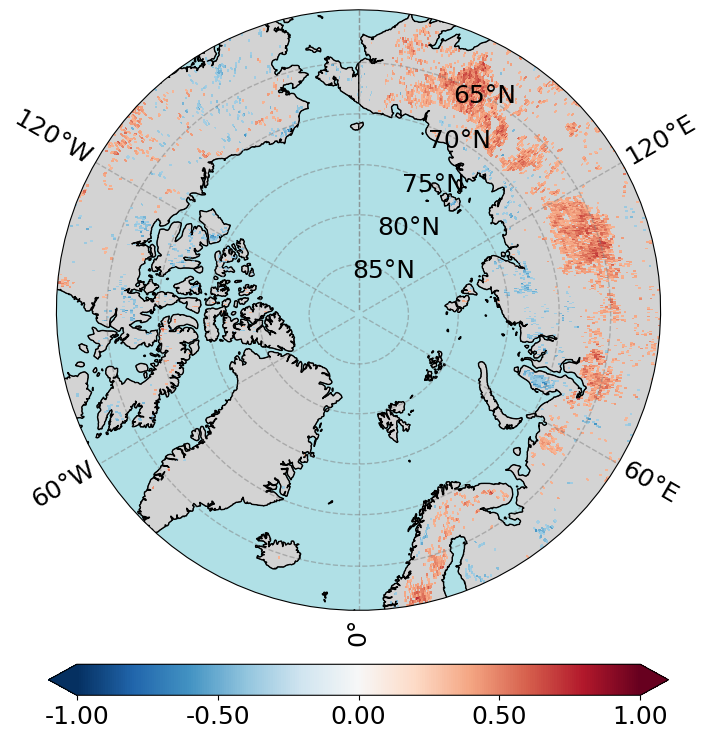

===== Overall, p < 0.05 =====
N: 5925
Mean rho: 0.27143673053077294
Median rho: 0.3907563025210084
Positive pixels: 4787
Negative pixels: 1138

===== HT, p < 0.05 =====
N: 1188
Mean rho: 0.2147228361720198
Median rho: 0.36764705882352944
Positive pixels: 902
Negative pixels: 286

===== PT, p < 0.05 =====
N: 1203
Mean rho: -0.10456915453211696
Median rho: -0.35406162464986
Positive pixels: 446
Negative pixels: 757

===== MT, p < 0.05 =====
N: 3534
Mean rho: 0.4184970548739691
Median rho: 0.4212885154061625
Positive pixels: 3439
Negative pixels: 95


In [16]:
lat_n, lon_n = annual_max_ndvi_all.shape[:2]
rho_map_ndvi = np.full((lat_n, lon_n), np.nan)
p_map_ndvi = np.full((lat_n, lon_n), np.nan)

for i in range(lat_n):
    for j in range(lon_n):

        med_ts = MED_doy[i,j,:]
        ndvi_ts = annual_max_ndvi_all[i,j,:]

        valid = (
            np.isfinite(med_ts) &
            np.isfinite(ndvi_ts)
        )

        if np.sum(valid) < 30:
            continue

        try:

            med_dt = linear_detrend(med_ts[valid])
            ndvi_dt = linear_detrend(ndvi_ts[valid])

            rho, p = spearmanr(
                med_dt,
                ndvi_dt
            )

            rho_map_ndvi[i,j] = rho
            p_map_ndvi[i,j] = p

        except:
            pass

rho_sig_ndvi = np.where(
    p_map_ndvi < 0.05,
    rho_map_ndvi,
    np.nan
)

fig, ax = plot_Northpole(
    domain_lon_60,
    domain_lat_60,
    rho_sig_ndvi,
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    vcenter=0,
    label_title=None
    )

plt.show()
#fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Spearman Correlation Between MED and Annual Maximum NDVI.png", dpi=300, bbox_inches="tight")
fig.savefig("C:/Users/nayou/journal_publish/Original_Figures_300dpi/Figures_300dpi/Trend/Spearman_Correlation_Between_MED_and_Annual_Max_NDVI_Detrended.png", dpi=300, bbox_inches="tight")
plt.close(fig)


# 95% significant pixels
sig_mask = p_map_ndvi < 0.05

# Total significant correlation
rho_sig_vals = rho_map_ndvi[sig_mask & np.isfinite(rho_map_ndvi)]

print("===== Overall, p < 0.05 =====")
print("N:", rho_sig_vals.size)
print("Mean rho:", np.nanmean(rho_sig_vals))
print("Median rho:", np.nanmedian(rho_sig_vals))
print("Positive pixels:", np.sum(rho_sig_vals > 0))
print("Negative pixels:", np.sum(rho_sig_vals < 0))

regime_info = {
    0: "HT",
    1: "PT",
    2: "MT"
}

# Regime-wise significant correlation
for regime_id, regime_name in regime_info.items():

    regime_mask = TB_cluster == regime_id

    valid = (
        sig_mask &
        regime_mask &
        np.isfinite(rho_map_ndvi)
    )

    rho_vals_ndvi = rho_map_ndvi[valid]

    print(f"\n===== {regime_name}, p < 0.05 =====")
    print("N:", rho_vals_ndvi.size)

    if rho_vals_ndvi.size > 0:
        print("Mean rho:", np.nanmean(rho_vals_ndvi))
        print("Median rho:", np.nanmedian(rho_vals_ndvi))
        print("Positive pixels:", np.sum(rho_vals_ndvi > 0))
        print("Negative pixels:", np.sum(rho_vals_ndvi < 0))
    else:
        print("No significant pixels")

### Statistical Significance of Correlations Between Snowmelt Timing (MED) and Annual Maximum NDVI

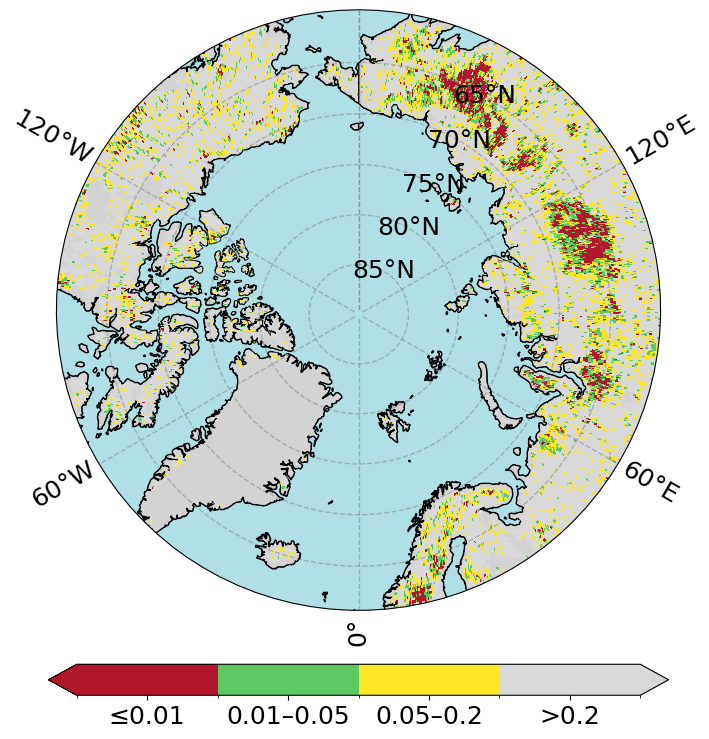

In [17]:
# Divide the p-value into 0.01, 0.05, and 0.2
p_corr_class = np.full_like(p_map_ndvi, np.nan, dtype=float)

p_corr_class[p_map_ndvi <= 0.01] = 0
p_corr_class[(p_map_ndvi > 0.01) & (p_map_ndvi <= 0.05)] = 1
p_corr_class[(p_map_ndvi > 0.05) & (p_map_ndvi <= 0.2)] = 2
p_corr_class[p_map_ndvi > 0.2] = 3

color_list = [
    "#b2182b",  # p <= 0.01
    "#5ec962",  # 0.01 < p <= 0.05
    "#fde725",  # 0.05 < p <= 0.2
    "#d9d9d9"   # p > 0.2
]

cmap = mcolors.ListedColormap(color_list)

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
ticks = [0, 1, 2, 3]
ticklabels = ["≤0.01", "0.01–0.05", "0.05–0.2", ">0.2"]

fig_p_corr, ax_p_corr = plot_Northpole(
    domain_lon_60,
    domain_lat_60,
    p_corr_class,
    label_title=None,
    cmap=cmap,
    bounds=bounds,
    ticks=ticks,
    ticklabels=ticklabels
)

#fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/P-value Classification of Spearman Correlation Between MED and Annual Maximum NDVI.png", dpi=300, bbox_inches="tight")
fig.savefig("C:/Users/nayou/journal_publish/Original_Figures_300dpi/Figures_300dpi/Trend/P_value_Classification_of_Spearman_Correlation_Between_MED_and_Annual_Max_NDVI.png", dpi=300, bbox_inches="tight")

## Correlation Between Snowmelt Timing and Peak NDVI Timing

To assess the relationship between snowmelt timing and vegetation phenology, pixel-wise Spearman correlations were calculated between annual MED and the timing of annual maximum NDVI. This analysis evaluates whether interannual variations in snowmelt timing are linked to shifts in the timing of peak vegetation development.

### Figure 3d. Interannual Spearman Correlation Analysis with MED

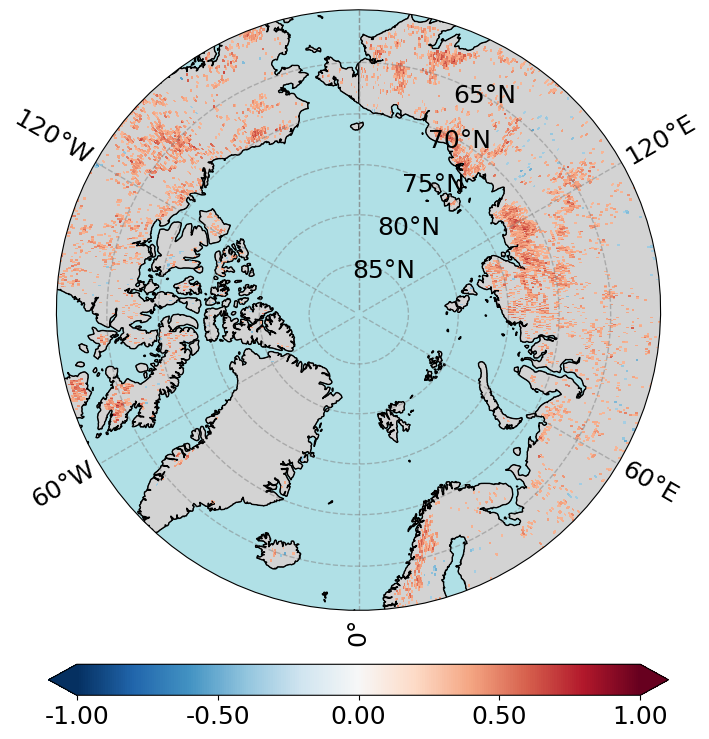

===== Overall, p < 0.05 =====
N: 5779
Mean rho: 0.3976031011021549
Median rho: 0.3997198879551821
Positive pixels: 5617
Negative pixels: 162

===== HT, p < 0.05 =====
N: 1218
Mean rho: 0.36071476301138794
Median rho: 0.38711484593837536
Positive pixels: 1146
Negative pixels: 72

===== PT, p < 0.05 =====
N: 2284
Mean rho: 0.40181846013706063
Median rho: 0.40140056022408965
Positive pixels: 2230
Negative pixels: 54

===== MT, p < 0.05 =====
N: 2277
Mean rho: 0.41310688492245784
Median rho: 0.4047619047619048
Positive pixels: 2241
Negative pixels: 36


In [18]:
lat_n, lon_n = annual_max_doy_all.shape[:2]

rho_map_doy = np.full((lat_n, lon_n), np.nan)
p_map_doy = np.full((lat_n, lon_n), np.nan)

for i in range(lat_n):
    for j in range(lon_n):

        med_ts = MED_doy[i, j, :]
        ndvi_ts_doy = annual_max_doy_all[i, j, :]

        valid = (
            np.isfinite(med_ts) &
            np.isfinite(ndvi_ts_doy)
        )

        if np.sum(valid) < 30:
            continue

        try:
            med_dt = linear_detrend(med_ts[valid])
            ndvi_doy_dt = linear_detrend(ndvi_ts_doy[valid])

            rho, p = spearmanr(
                med_dt,
                ndvi_doy_dt
            )

            rho_map_doy[i, j] = rho
            p_map_doy[i, j] = p

        except Exception:
            pass

rho_sig_doy = np.where(
    p_map_doy < 0.05,
    rho_map_doy,
    np.nan
)

fig, ax = plot_Northpole(
    domain_lon_60,
    domain_lat_60,
    rho_sig_doy,
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    vcenter=0,
    label_title=None
    )

plt.show()
#fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Spearman Correlation Between MED and Peak NDVI DOY.png", dpi=300, bbox_inches="tight")
fig.savefig("C:/Users/nayou/journal_publish/Original_Figures_300dpi/Figures_300dpi/Trend/Spearman_Correlation_Between_MED_and_Peak_NDVI_DOY_Detrended.png", dpi=300, bbox_inches="tight")

# 95% significant pixels
sig_mask = p_map_doy < 0.05

# Total significant correlation
rho_sig_vals_doy = rho_map_doy[sig_mask & np.isfinite(rho_map_doy)]

print("===== Overall, p < 0.05 =====")
print("N:", rho_sig_vals_doy.size)
print("Mean rho:", np.nanmean(rho_sig_vals_doy))
print("Median rho:", np.nanmedian(rho_sig_vals_doy))
print("Positive pixels:", np.sum(rho_sig_vals_doy > 0))
print("Negative pixels:", np.sum(rho_sig_vals_doy < 0))

regime_info = {
    0: "HT",
    1: "PT",
    2: "MT"
}

for regime_id, regime_name in regime_info.items():

    regime_mask = TB_cluster == regime_id

    valid = (
        sig_mask &
        regime_mask &
        np.isfinite(rho_map_doy)
    )

    rho_vals_doy = rho_map_doy[valid]

    print(f"\n===== {regime_name}, p < 0.05 =====")
    print("N:", rho_vals_doy.size)

    if rho_vals_doy.size > 0:
        print("Mean rho:", np.nanmean(rho_vals_doy))
        print("Median rho:", np.nanmedian(rho_vals_doy))
        print("Positive pixels:", np.sum(rho_vals_doy > 0))
        print("Negative pixels:", np.sum(rho_vals_doy < 0))
    else:
        print("No significant pixels")

### Statistical Significance of Correlations Between Snowmelt Timing (MED) and Peak NDVI DOY

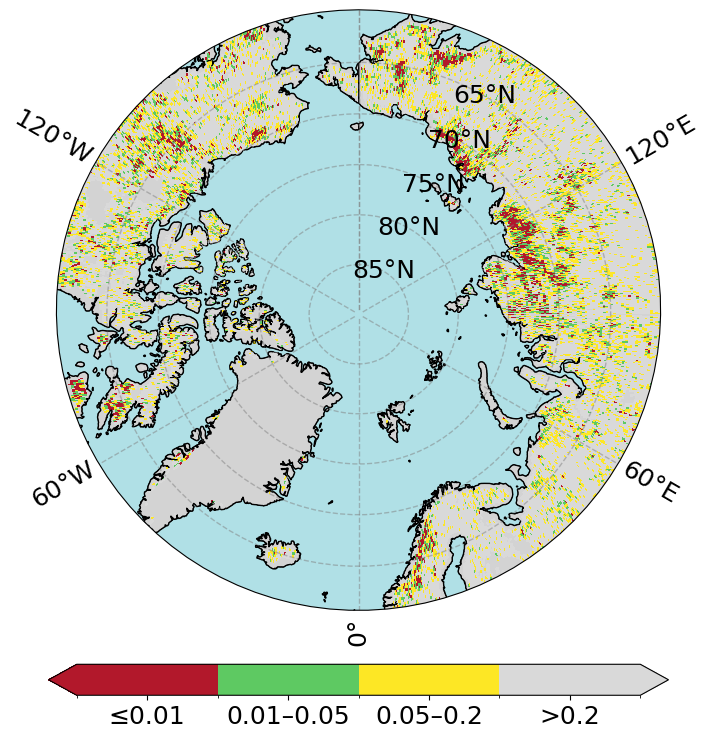

In [19]:
# Divide the p-value into 0.01, 0.05, and 0.2
p_corr_class = np.full_like(p_map_doy, np.nan, dtype=float)

p_corr_class[p_map_doy <= 0.01] = 0
p_corr_class[(p_map_doy > 0.01) & (p_map_doy <= 0.05)] = 1
p_corr_class[(p_map_doy > 0.05) & (p_map_doy <= 0.2)] = 2
p_corr_class[p_map_doy > 0.2] = 3

color_list = [
    "#b2182b",  # p <= 0.01
    "#5ec962",  # 0.01 < p <= 0.05
    "#fde725",  # 0.05 < p <= 0.2
    "#d9d9d9"   # p > 0.2
]

cmap = mcolors.ListedColormap(color_list)

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
ticks = [0, 1, 2, 3]
ticklabels = ["≤0.01", "0.01–0.05", "0.05–0.2", ">0.2"]

fig_p_corr, ax_p_corr = plot_Northpole(
    domain_lon_60,
    domain_lat_60,
    p_corr_class,
    label_title=None,
    cmap=cmap,
    bounds=bounds,
    ticks=ticks,
    ticklabels=ticklabels
)

#fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/P-value Classification of Spearman Correlation Between MED and Peak NDVI DOY.png", dpi=300, bbox_inches="tight")
fig.savefig("C:/Users/nayou/journal_publish/Original_Figures_300dpi/Figures_300dpi/Trend/P_value_Classification_of_Spearman_Correlation_Between_MED_and_Peak_NDVI_DOY.png", dpi=300, bbox_inches="tight")

## Relationship Between Snowmelt Timing and Start of Season (SOS)

This section investigates the relationship between snowmelt timing (MED only) and vegetation green-up timing using the start of season (SOS) derived from the GIMMS NDVI dataset. Previous studies have suggested that earlier snowmelt can substantially advance spring vegetation green-up, particularly in snow-dominated ecosystems. Motivated by these findings, this analysis examines whether variations in snowmelt timing are associated with corresponding changes in vegetation phenology across the Arctic.

Following the approach of Zheng et al. (Earlier snowmelt predominates advanced spring vegetation greenup in Alaska, 2022), SOS was estimated using a relative threshold method applied to annual NDVI time series. For each pixel and year, NDVI values were normalized using the annual minimum and maximum NDVI, and SOS was defined as the first day of year (DOY) when the normalized NDVI exceeded 20% of the annual NDVI amplitude. The SOS search was restricted to DOY 60–250 to focus on the primary growing season and avoid spurious detections during winter and late-season periods.

To derive annual SOS fields, all half-monthly NDVI observations within each year were first sorted by DOY. The threshold-based SOS algorithm was then applied to each pixel independently, generating a spatially distributed SOS dataset for 1988–2022. These SOS estimates were subsequently used to evaluate the association between snowmelt timing and vegetation green-up timing across the Arctic.


### Define functions

In [ ]:
def extract_sos_one_year(
    ndvi_ts,
    doy,
    threshold=0.2,
    doy_min=60,
    doy_max=250
):
    ndvi_ts = np.asarray(ndvi_ts, dtype=float)
    doy = np.asarray(doy)

    valid = np.isfinite(ndvi_ts)

    if np.sum(valid) < 4:
        return np.nan

    ndvi_valid = ndvi_ts[valid]
    doy_valid = doy[valid]

    order = np.argsort(doy_valid)
    ndvi_valid = ndvi_valid[order]
    doy_valid = doy_valid[order]

    # Annual normalization based on the entire valid NDVI
    ndvi_min = np.nanmin(ndvi_valid)
    ndvi_max = np.nanmax(ndvi_valid)
    amp = ndvi_max - ndvi_min

    if not np.isfinite(amp) or amp <= 0:
        return np.nan

    ndvi_ratio = (ndvi_valid - ndvi_min) / amp

    # SOS search window
    search_window = (
        (doy_valid >= doy_min) &
        (doy_valid <= doy_max)
    )

    idx = np.where(
        (ndvi_ratio >= threshold) &
        search_window
    )[0]

    if len(idx) == 0:
        return np.nan

    return doy_valid[idx[0]]

### Generation of Annual SOS Data from GIMMS NDVI

In [ ]:
# Settings
start_year = 1988
end_year = 2022
years = np.arange(start_year, end_year + 1)

threshold = 0.2

base_ndvi_dir = f'{cpuserver_data_FP}/personal_data/project_snow/NDVI/NDVI_GIMMS/NDVI_25km_new'
out_dir = f'{cpuserver_data_FP}/personal_data/project_snow/NDVI/NDVI_GIMMS/SOS_25km'
os.makedirs(out_dir, exist_ok=True)


# Read 25km NDVI files and calculate SOS
SOS_all = None
domain_lat = None
domain_lon = None

for y_idx, year in enumerate(years):

    year_dir = os.path.join(base_ndvi_dir, str(year))
    ndvi_files = sorted(glob.glob(os.path.join(year_dir, 'GIMMS_NDVI_*_25km.nc')))

    print(f'\nProcessing {year}: {len(ndvi_files)} files')

    if len(ndvi_files) == 0:
        print(f'No files found for {year}')
        continue

    ndvi_year_list = []
    doy_year_list = []

    for f in ndvi_files:

        with nc.Dataset(f, 'r') as ds:

            ndvi = ds.variables['NDVI'][:].astype(float)

            # Masked array
            if np.ma.isMaskedArray(ndvi):
                ndvi = ndvi.filled(np.nan)

            time_var = ds.variables['time']
            time_values = time_var[:]

            dates = num2date(
                time_values,
                units=time_var.units,
                calendar=getattr(time_var, 'calendar', 'standard')
            )

            current_date = dates[0]
            doy = current_date.timetuple().tm_yday

            if domain_lat is None:
                lat_1d = ds.variables['lat'][:]
                lon_1d = ds.variables['lon'][:]
                domain_lon, domain_lat = np.meshgrid(lon_1d, lat_1d)

            ndvi_year_list.append(ndvi)
            doy_year_list.append(doy)

    ndvi_year = np.stack(ndvi_year_list, axis=2)
    doy_year = np.array(doy_year_list)

    # Sort DOY order to prevent any potential issues
    order = np.argsort(doy_year)
    ndvi_year = ndvi_year[:, :, order]
    doy_year = doy_year[order]

    if SOS_all is None:
        lat_n, lon_n = ndvi_year.shape[:2]
        SOS_all = np.full((lat_n, lon_n, len(years)), np.nan)

    for i in range(lat_n):
        for j in range(lon_n):

            SOS_all[i, j, y_idx] = extract_sos_one_year(
                ndvi_year[i, j, :],
                doy_year,
                threshold=threshold,
                doy_min=60,
                doy_max=250
            )

    print(
        f'{year} SOS range:',
        np.nanmin(SOS_all[:, :, y_idx]),
        np.nanmax(SOS_all[:, :, y_idx])
    )



# Save SOS (lat, lon, year)
out_file = os.path.join(
    out_dir,
    f'GIMMS_SOS_25km_{start_year}_{end_year}.nc'
)

with nc.Dataset(out_file, 'w', format='NETCDF4') as dst:

    dst.createDimension('lat', lat_n)
    dst.createDimension('lon', lon_n)
    dst.createDimension('year', len(years))

    lat_var = dst.createVariable(
        'lat',
        'f4',
        ('lat',)
    )

    lon_var = dst.createVariable(
        'lon',
        'f4',
        ('lon',)
    )

    year_var = dst.createVariable(
        'year',
        'i4',
        ('year',)
    )

    sos_var = dst.createVariable(
        'SOS',
        'f4',
        ('lat', 'lon', 'year'),
        zlib=True,
        complevel=4,
        fill_value=np.nan
    )

    lat_var[:] = domain_lat[:, 0]
    lon_var[:] = domain_lon[0, :]
    year_var[:] = years

    sos_var[:] = SOS_all

    lat_var.units = 'degrees_north'
    lon_var.units = 'degrees_east'

    year_var.long_name = 'Year'

    sos_var.units = 'DOY'
    sos_var.long_name = (
        'Start of Season derived from annual normalized GIMMS NDVI'
    )

    sos_var.description = (
        'First day when normalized NDVI exceeds 20 percent of annual amplitude'
    )

    dst.description = (
        'Annual SOS derived from GIMMS NDVI3g using relative threshold method'
    )

print(f'Saved: {out_file}')

## Calculate the 35-year SOS trend

In [ ]:
# Load SOS file
start_year, end_year = 1988, 2022
years = np.arange(start_year, end_year + 1)
min_years = 30

sos_file = (
    f'{cpuserver_data_FP}/personal_data/project_snow/NDVI/NDVI_GIMMS/SOS_25km/'
    f'GIMMS_SOS_25km_{start_year}_{end_year}.nc'
)

with nc.Dataset(sos_file, 'r') as ds:
    lat = ds.variables['lat'][:]
    lon = ds.variables['lon'][:]
    SOS_all = ds.variables['SOS'][:]

SOS_all = np.array(SOS_all, dtype=np.float32)

if np.ma.isMaskedArray(SOS_all):
    SOS_all = SOS_all.filled(np.nan)

print("SOS_all:", SOS_all.shape)
print("SOS range:", np.nanmin(SOS_all), np.nanmax(SOS_all))
print("SOS mean:", np.nanmean(SOS_all))


# Common preprocessing
# Cut SOS above north of 60N
SOS_all = SOS_all[lat > 60, :, :]

domain_lat_60 = domain_lat[lat > 60, :]
domain_lon_60 = domain_lon[lat > 60, :]

print("SOS_all 60N:", SOS_all.shape)
print("domain_lat_60:", domain_lat_60.shape)

# Exclude cluster 3 globally
SOS_all[TB_cluster == 3, :] = np.nan

# Apply yearly valid mask
for yi, year in enumerate(years):
    bad = (load_mask_for_year(year) == 0)

    slice_sos = SOS_all[:, :, yi]
    slice_sos[bad] = np.nan
    SOS_all[:, :, yi] = slice_sos

print("After masking SOS range:", np.nanmin(SOS_all), np.nanmax(SOS_all))
print("After masking SOS mean:", np.nanmean(SOS_all))

In [ ]:
# Plot mean SOS
SOS_mean = np.nanmean(SOS_all, axis=2)

print("Mean SOS range:", np.nanmin(SOS_mean), np.nanmax(SOS_mean))
print("Mean SOS mean:", np.nanmean(SOS_mean))

plot_Northpole(
    domain_lon_60,
    domain_lat_60,
    SOS_mean,
    cmap='Spectral_r',
    vmin=60,
    vmax=250,
    vcenter=np.nanmean(SOS_mean),
    label_title='Mean SOS (DOY)'
)


# MK test and Sen's slope for SOS
lat_n, lon_n = SOS_all.shape[:2]

SOS_mk_p = np.full((lat_n, lon_n), np.nan)
SOS_mk_slope = np.full((lat_n, lon_n), np.nan)

for i in range(lat_n):
    for j in range(lon_n):

        ts = SOS_all[i, j, :]

        valid = np.isfinite(ts)

        if np.sum(valid) < min_years:
            continue

        try:
            result = original_test(ts[valid])

            SOS_mk_p[i, j] = result.p
            SOS_mk_slope[i, j] = result.slope

        except:
            pass

print("SOS MK p range:", np.nanmin(SOS_mk_p), np.nanmax(SOS_mk_p))
print("SOS Sen slope range:", np.nanmin(SOS_mk_slope), np.nanmax(SOS_mk_slope))
print("SOS Sen slope mean:", np.nanmean(SOS_mk_slope))


# Plot and summarize trend
fig_trend, ax_trend, fig_slope, ax_slope, SOS_trend, SOS_slope_sig = plot_and_summarize_trend(
    SOS_mk_p,
    SOS_mk_slope,
    domain_lon_60,
    domain_lat_60,
    var_name='SOS',
    slope_unit='days/year',
    significant_level=0.05,
    slope_vmin=np.nanmin(SOS_mk_slope),
    slope_vmax=np.nanmax(SOS_mk_slope)
)

## Correlation Between Snowmelt Timing and SOS

To evaluate the impact of snowmelt timing on spring vegetation emergence, pixel-wise Spearman correlations were calculated between annual MED and SOS. This analysis investigates whether earlier snowmelt is associated with earlier vegetation green-up across Arctic ecosystems.

In [ ]:
lat_n, lon_n = SOS_all.shape[:2]

rho_map_sos = np.full((lat_n, lon_n), np.nan)
p_map_sos = np.full((lat_n, lon_n), np.nan)

for i in range(lat_n):
    for j in range(lon_n):

        med_ts = MED_doy[i, j, :]
        sos_ts = SOS_all[i, j, :]

        valid = (
            np.isfinite(med_ts) &
            np.isfinite(sos_ts)
        )

        if np.sum(valid) < 30:
            continue

        try:
            med_dt = linear_detrend(med_ts[valid])
            sos_dt = linear_detrend(sos_ts[valid])

            rho, p = spearmanr(
                med_dt,
                sos_dt
            )

            rho_map_sos[i, j] = rho
            p_map_sos[i, j] = p

        except Exception:
            pass


rho_sig_sos = np.where(
    p_map_sos < 0.05,
    rho_map_sos,
    np.nan
)

fig, ax = plot_Northpole(
    domain_lon_60,
    domain_lat_60,
    rho_sig_sos,
    cmap='RdBu_r',
    vmin=np.nanmin(rho_map_sos),
    vmax=np.nanmax(rho_map_sos),
    vcenter=0,
    label_title=None
)

fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Spearman Correlation Between MED and SOS.png", dpi=300, bbox_inches="tight")

# 95% significant pixels
sig_mask_sos = p_map_sos < 0.05

rho_sig_vals_sos = rho_map_sos[
    sig_mask_sos & np.isfinite(rho_map_sos)
]

# Overall Statistical Significance
print("===== MED vs SOS, p < 0.05 =====")
print("N:", rho_sig_vals_sos.size)
print("Mean rho:", np.nanmean(rho_sig_vals_sos))
print("Median rho:", np.nanmedian(rho_sig_vals_sos))
print("Positive pixels:", np.sum(rho_sig_vals_sos > 0))
print("Negative pixels:", np.sum(rho_sig_vals_sos < 0))

regime_info = {
    0: "HT",
    1: "PT",
    2: "MT"
}

for regime_id, regime_name in regime_info.items():

    regime_mask = TB_cluster == regime_id

    valid = (
        sig_mask_sos &
        regime_mask &
        np.isfinite(rho_map_sos)
    )

    rho_vals_sos = rho_map_sos[valid]

    print(f"\n===== {regime_name}, p < 0.05 =====")
    print("N:", rho_vals_sos.size)

    if rho_vals_sos.size > 0:
        print("Mean rho:", np.nanmean(rho_vals_sos))
        print("Median rho:", np.nanmedian(rho_vals_sos))
        print("Positive pixels:", np.sum(rho_vals_sos > 0))
        print("Negative pixels:", np.sum(rho_vals_sos < 0))
    else:
        print("No significant pixels")